In [56]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [84]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [2]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [3]:
N_AB_sub = np.loadtxt('../../../misc/ForSebastian/N_AB_sub_BolPlanck.dat')

cols = [
    "host_id", "logMh", "ch", "a_50h",
    "Xoff_h", "Spin_h", "Spin_Bullock_h", "ch_K",
    "x_h", "y_h", "z_h", "R_vir",
    "id", "log10Mvir", "Rvir", "rs", "vrms", "scale_of_last_MM",
    "vmax", "x", "y", "z", "vx", "vy", "vz",
    "Jx", "Jy", "Jz", "Spin", "Tidal_Force", "Tidal_ID",
    "Mmvir_all", "M200b", "M200c", "M500c",
    "Xoff", "Voff", "Spin_Bullock",
    "b_to_a", "c_to_a",
    "Ax", "Ay", "Az", "T_by_U",
    "M_pe_Behroozi", "M_pe_Diemer",
    "Macc", "Mpeak", "Vacc", "Vpeak", "Halfmass_Scale",
    "Acc_Rate_Inst", "Acc_Rate_100Myr", "Acc_Rate_1Tdyn",
    "Acc_Rate_2Tdyn", "Acc_Rate_Mpeak",
    "Mpeak_Scale", "Acc_Scale", "First_Acc_Scale",
    "First_Acc_Mvir", "First_Acc_Vmax", "Vmax_at_Mpeak",
    "Tidal_Force_Tdyn"
]

df = pd.DataFrame(N_AB_sub, columns=cols)

In [ ]:
N_AB_sub = np.loadtxt('../../../misc/ForSebastian/N_AB_sub_BolPlanck.dat')

cols = [
    "host_id", "logMh", "ch", "a_50h",
    "Xoff_h", "Spin_h", "Spin_Bullock_h", "ch_K",
    "x_h", "y_h", "z_h", "R_vir",
    "id", "log10Mvir", "Rvir", "rs", "vrms", "scale_of_last_MM",
    "vmax", "x", "y", "z", "vx", "vy", "vz",
    "Jx", "Jy", "Jz", "Spin", "Tidal_Force", "Tidal_ID",
    "Mmvir_all", "M200b", "M200c", "M500c",
    "Xoff", "Voff", "Spin_Bullock",
    "b_to_a", "c_to_a",
    "Ax", "Ay", "Az", "T_by_U",
    "M_pe_Behroozi", "M_pe_Diemer",
    "Macc", "Mpeak", "Vacc", "Vpeak", "Halfmass_Scale",
    "Acc_Rate_Inst", "Acc_Rate_100Myr", "Acc_Rate_1Tdyn",
    "Acc_Rate_2Tdyn", "Acc_Rate_Mpeak",
    "Mpeak_Scale", "Acc_Scale", "First_Acc_Scale",
    "First_Acc_Mvir", "First_Acc_Vmax", "Vmax_at_Mpeak",
    "Tidal_Force_Tdyn"
]

df = pd.DataFrame(N_AB_sub, columns=cols)

In [58]:
def build_host_table(df, mass_thresh):

    host_id_unique = np.sort(df["host_id"].unique())

    logMvir   = np.zeros(len(host_id_unique))
    log1pz50  = np.zeros(len(host_id_unique))
    logc      = np.zeros(len(host_id_unique))
    logNsub   = np.zeros(len(host_id_unique))
    logfsub   = np.zeros(len(host_id_unique))

    groups = df.groupby("host_id")

    for i, hid in enumerate(host_id_unique):

        subset = groups.get_group(hid)
        subset1 = subset[subset["log10Mvir"] >= mass_thresh]

        # --- host properties ---
        logMh_i  = subset["logMh"].mean()
        c_h_i    = subset["ch"].mean()
        a_half_i = subset["a_50h"].mean()

        # --- derived quantities ---
        z50 = (1.0 / a_half_i) - 1.0

        Nsub_i = len(subset1)

        host_mass = 10**logMh_i
        sub_mass_total = np.sum(10**subset1["log10Mvir"])
        f_sub_i = sub_mass_total / host_mass

        # --- logs (with safety) ---
        logMvir[i]  = logMh_i
        log1pz50[i] = np.log10(1.0 + z50)

        logc[i] = np.log10(c_h_i)

        logNsub[i] = np.log10(Nsub_i) if Nsub_i > 0 else -np.inf

        logfsub[i] = np.log10(f_sub_i) if f_sub_i > 0 else -np.inf

        # if (i % 10000) == 0:
        #     print(i)

    small_df = pd.DataFrame({
        "host_id": host_id_unique,
        "logMvir": logMvir,
        "log1pz50": log1pz50,
        "logc": logc,
        "logNsub": logNsub,
        "logfsub": logfsub
    })

    return small_df

In [5]:
# Identify unique hosts and compute host-level properties
host_props = df.groupby("host_id")[["Xoff_h", "Spin_h", "R_vir"]].mean()

# Apply the cut
both_cut = host_props[
    (host_props["Xoff_h"]/host_props["R_vir"] <= 0.07) &
    (host_props["Spin_h"] <= 0.07)
].index

# Apply the cut
xoff_cut = host_props[
    (host_props["Xoff_h"]/host_props["R_vir"] <= 0.07)
].index

# Filter dataframe to keep only those hosts
both = df[df["host_id"].isin(both_cut)]
xoff = df[df["host_id"].isin(xoff_cut)]

In [6]:
both_df = build_host_table(both, mass_thresh=9.82)
xoff_df = build_host_table(xoff, mass_thresh=9.82)
full_df = build_host_table(df, mass_thresh=9.82)

0
10000
20000
30000
40000
50000
60000
70000
0
10000
20000
30000
40000
50000
60000
70000
0
10000
20000
30000
40000
50000
60000
70000
80000
90000


(0.0, 0.7)

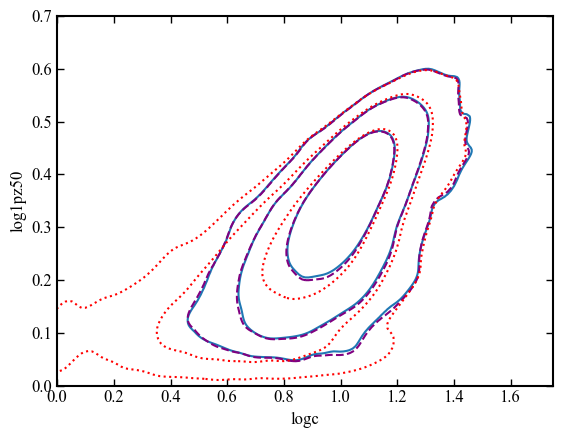

In [7]:
sns.kdeplot(x=both_df["logc"], y=both_df["log1pz50"], levels=levelz, color="C0", bw_adjust=1.5)
sns.kdeplot(x=xoff_df["logc"], y=xoff_df["log1pz50"], levels=levelz, color="purple", linestyles="--", bw_adjust=1.5)
sns.kdeplot(x=full_df["logc"], y=full_df["log1pz50"], levels=levelz, color="red", linestyles=":", bw_adjust=1.5)
plt.xlim(0, 1.75)
plt.ylim(0, 0.7)

### just the subsample

In [8]:
# both_df.to_csv("../../data/summary_tabs/bolshoi_full.csv")

In [9]:
bin_min = 13.1
bin_max = 13.3
subsample = full_df[(full_df["logMvir"] > bin_min) & (full_df["logMvir"] < bin_max)]

<Axes: xlabel='logMvir', ylabel='Density'>

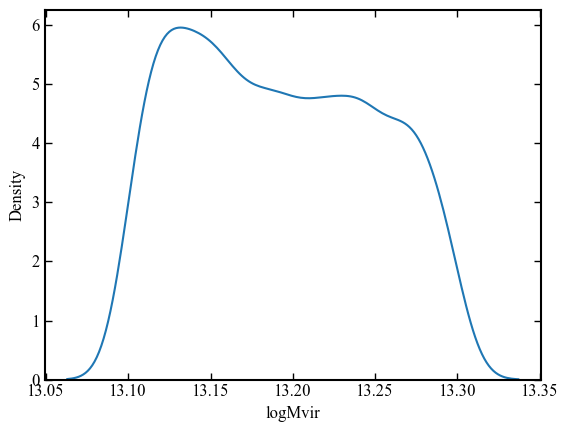

In [10]:
sns.kdeplot(subsample["logMvir"])
# np.save("../../data/summary_tabs/Mhost_bolshoi_131.npy", subsample["logMvir"].values)

### convergence test!

In [71]:
mpart = 1.5*10**8
N_part = np.logspace(np.log10(50), 3, 10)
mthresholds = np.log10(mpart*N_part)

In [72]:
bin_min = 13.0
bin_max = 13.2

rhos1 = []
for thresh in mthresholds:
    df_i = build_host_table(both, mass_thresh=thresh)
    ss_i = df_i[(df_i["logMvir"] > bin_min) & (df_i["logMvir"] < bin_max)]
    pz_i = jsm_stats.correlation(ss_i["log1pz50"], ss_i["logNsub"])
    pc_i = jsm_stats.correlation(ss_i["logc"], ss_i["logNsub"])
    rhos1.append([pz_i, pc_i])

rhos1 = np.array(rhos1)

In [73]:
bin_min = 13.2
bin_max = 13.4

rhos2 = []
for thresh in mthresholds:
    df_i = build_host_table(both, mass_thresh=thresh)
    ss_i = df_i[(df_i["logMvir"] > bin_min) & (df_i["logMvir"] < bin_max)]
    pz_i = jsm_stats.correlation(ss_i["log1pz50"], ss_i["logNsub"])
    pc_i = jsm_stats.correlation(ss_i["logc"], ss_i["logNsub"])
    rhos2.append([pz_i, pc_i])

rhos2 = np.array(rhos2)

In [74]:
bin_min = 13.4
bin_max = 13.6

rhos3 = []
for thresh in mthresholds:
    df_i = build_host_table(both, mass_thresh=thresh)
    ss_i = df_i[(df_i["logMvir"] > bin_min) & (df_i["logMvir"] < bin_max)]
    pz_i = jsm_stats.correlation(ss_i["log1pz50"], ss_i["logNsub"])
    pc_i = jsm_stats.correlation(ss_i["logc"], ss_i["logNsub"])
    rhos3.append([pz_i, pc_i])

rhos3 = np.array(rhos3)

In [75]:
bin_min = 13.6
bin_max = 13.8

rhos4 = []
for thresh in mthresholds:
    df_i = build_host_table(both, mass_thresh=thresh)
    ss_i = df_i[(df_i["logMvir"] > bin_min) & (df_i["logMvir"] < bin_max)]
    pz_i = jsm_stats.correlation(ss_i["log1pz50"], ss_i["logNsub"])
    pc_i = jsm_stats.correlation(ss_i["logc"], ss_i["logNsub"])
    rhos4.append([pz_i, pc_i])

rhos4 = np.array(rhos4)

In [76]:
bin_min = 13.8
bin_max = 14.0

rhos5 = []
for thresh in mthresholds:
    df_i = build_host_table(both, mass_thresh=thresh)
    ss_i = df_i[(df_i["logMvir"] > bin_min) & (df_i["logMvir"] < bin_max)]
    pz_i = jsm_stats.correlation(ss_i["log1pz50"], ss_i["logNsub"])
    pc_i = jsm_stats.correlation(ss_i["logc"], ss_i["logNsub"])
    rhos5.append([pz_i, pc_i])

rhos5 = np.array(rhos5)

In [ ]:
Nhosts = [2756, 1714, 1108, 651, 384]

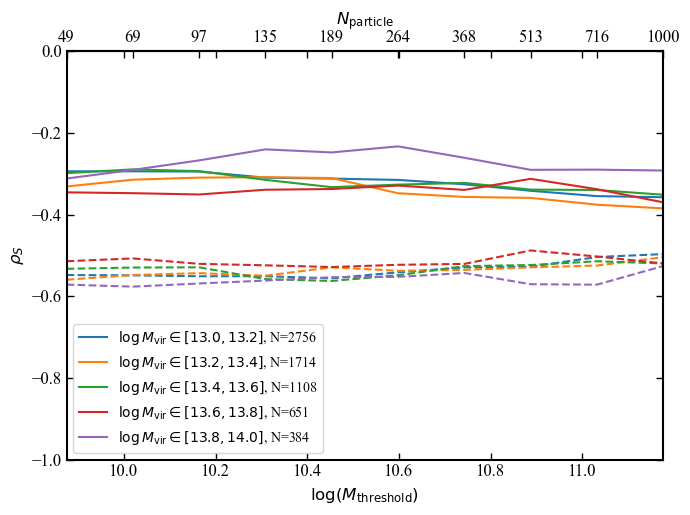

In [107]:
mpart = 1.5 * 10**8
N_part = np.logspace(np.log10(50), 3, 10)
mthresholds = np.log10(mpart * N_part)

fig, ax = plt.subplots(figsize=(double_textwidth, single_textwidth*1.5))

ax.plot(mthresholds, rhos1[:, 0], color="C0", label="$\\log M_{{\\rm vir}} \\in [13.0, 13.2]$, N=2756")
ax.plot(mthresholds, rhos2[:, 0], color="C1", label="$\\log M_{{\\rm vir}} \\in [13.2, 13.4]$, N=1714")
ax.plot(mthresholds, rhos3[:, 0], color="C2", label="$\\log M_{{\\rm vir}} \\in [13.4, 13.6]$, N=1108")
ax.plot(mthresholds, rhos4[:, 0], color="C3", label="$\\log M_{{\\rm vir}} \\in [13.6, 13.8]$, N=651")
ax.plot(mthresholds, rhos5[:, 0], color="C4", label="$\\log M_{{\\rm vir}} \\in [13.8, 14.0]$, N=384")

ax.plot(mthresholds, rhos1[:, 1], color="C0", ls="--")
ax.plot(mthresholds, rhos2[:, 1], color="C1", ls="--")
ax.plot(mthresholds, rhos3[:, 1], color="C2", ls="--")
ax.plot(mthresholds, rhos4[:, 1], color="C3", ls="--")
ax.plot(mthresholds, rhos5[:, 1], color="C4", ls="--")

ax.set_ylim(-1, 0)
ax.set_xlabel(r"$\log(M_{\rm threshold})$")

# --- secondary x-axis ---
def logM_to_N(logM):
    return 10**logM / mpart

def N_to_logM(N):
    return np.log10(mpart * N)

secax = ax.secondary_xaxis('top', functions=(logM_to_N, N_to_logM))
secax.set_xlabel(r"$N_{\rm particle}$")

# Optional: make ticks nice (log-spaced like your original array)
secax.set_xticks(N_part)
secax.set_xticklabels([f"{int(n)}" for n in N_part])

ax.legend(fontsize=10)
ax.set_xlim(mthresholds.min(), mthresholds.max())
ax.set_ylabel("$\\rho_S$")

plt.tight_layout()
plt.show()